# Explore 01

Good question. This is where many people mess up.

## The correct answer

Your **main file for matrix profiling** is:

`data/processed/crypto/1min/BTCUSDT_1m_processed.parquet`

(and similarly for ETH later)

## Why not the others

### Raw file

`data/raw/...BTCUSDT_1m_raw.parquet`

Think of this like **unprocessed ingredients**.

- no returns
- no volatility
- no cleaned structure for analysis

Not suitable for motif discovery.

### Metadata files

- `.json`
- `.csv`

These are:

- diagnostics
- audit logs

Useful for analysis, but not input to STUMPY.

## Analogy

You are doing motif discovery like pattern mining in signals.

- raw file = raw sensor data
- processed file = engineered signal
- metadata = health report

You do not mine patterns on the health report.
You mine patterns on the signal.

## What you actually feed into STUMPY

Even inside the processed file, you do **not** pass the whole dataframe.

You extract **one 1D series**.

Example:

```python
series = df["log_return"].values
```

## The real pipeline

### Step 1

Load:

```python
df = pd.read_parquet("data/processed/...BTCUSDT_1m_processed.parquet")
```

### Step 2

Select signal:

```python
series = df["log_return"].dropna().values
```

### Step 3

Feed to STUMPY:

```python
mp = stumpy.stump(series, m=window_size)
```

## Signal choice is a thesis-level decision

| Option | Good? | Why |
| --- | --- | --- |
| `close` | No | non-stationary |
| `log_return` | Best start | simplest defensible first signal |
| `pct_return` | Similar but weaker start | less clean than log-return |
| `volatility` | Good later | useful for second-stage experiments |
| `realized_volatility` | Good advanced option | suitable for later analysis |

Recommended start:

```python
df = pd.read_parquet("...BTCUSDT_1m_processed.parquet")
series = df["log_return"].dropna().values
```

## One critical thing

Your data has missing 1-minute intervals.

Before STUMPY you should decide:

### Option A: simple start

```python
series = df["log_return"].dropna().values
```

This ignores gaps.

### Option B: better later

- reindex to full timeline
- forward-fill price
- recompute returns

## Final mental model

Think like this:

- File = dataset container
- Column = signal candidate
- Series = actual input to algorithm

Matrix profile only sees:

```python
[x1, x2, x3, ..., xT]
```

## Your next action

In your notebook:

```python
df = pd.read_parquet("data/processed/crypto/1min/BTCUSDT_1m_processed.parquet")
series = df["log_return"].dropna()
series.plot(figsize=(12, 4))
```

Look at it.

If it looks clean, you are ready for STUMPY.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

processed_path = project_root / "data" / "processed" / "crypto" / "1min" / "BTCUSDT_1m_processed.parquet"
processed_path

WindowsPath('C:/Users/learn/OneDrive/Desktop/Masters Thesis/MastersThesis/data/processed/crypto/1min/BTCUSDT_1m_processed.parquet')

In [2]:
df = pd.read_parquet(processed_path)
series = df["log_return"].dropna()

print(f"Rows in dataframe: {len(df):,}")
print(f"Rows in log_return series after dropna: {len(series):,}")
print(f"Series start: {df.loc[series.index[0], 'timestamp']}")
print(f"Series end: {df.loc[series.index[-1], 'timestamp']}")

Rows in dataframe: 4,502,648
Rows in log_return series after dropna: 4,502,647
Series start: 2017-08-17 04:01:00+00:00
Series end: 2026-03-15 23:59:00+00:00


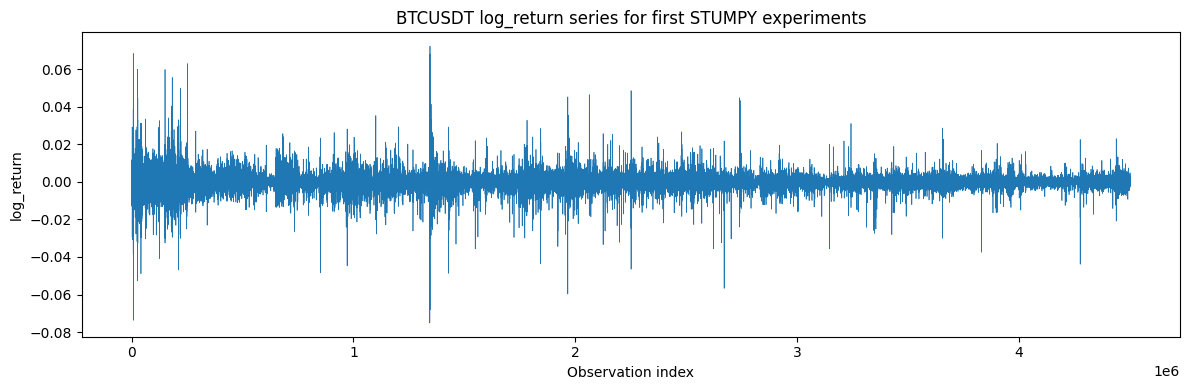

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
series.plot(ax=ax, linewidth=0.5, color="tab:blue")
ax.set_title("BTCUSDT log_return series for first STUMPY experiments")
ax.set_xlabel("Observation index")
ax.set_ylabel("log_return")
plt.tight_layout()
plt.show()

If you want next step, the next notebook should cover:

- how to pick window size `m`
- how to run the first matrix profile in a few lines without blowing up compute

In [4]:
import os
file_path = r"../../data/processed/crypto/1min/BTCUSDT_1m_processed.parquet"
size_bytes = os.path.getsize(file_path)
print(f"File: {file_path}")
print(f"Size: {size_bytes / (1024 * 1024):.2f} MB")

File: ../../data/processed/crypto/1min/BTCUSDT_1m_processed.parquet
Size: 353.73 MB


## 1. Setup and Imports
Adding a comprehensive data inspection and summary section.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths relative to project root
project_root = Path("../../").resolve()
data_dir = project_root / "data"

btc_processed_path = data_dir / "processed/crypto/1min/BTCUSDT_1m_processed.parquet"
eth_processed_path = data_dir / "processed/crypto/1min/ETHUSDT_1m_processed.parquet"
btc_missing_path = data_dir / "metadata/BTCUSDT_1m_missing_timestamps.csv"
eth_missing_path = data_dir / "metadata/ETHUSDT_1m_missing_timestamps.csv"

## 2. Load Data

In [6]:
# Load Parquet files
df_btc = pd.read_parquet(btc_processed_path)
df_eth = pd.read_parquet(eth_processed_path)

# Convert timestamp to datetime UTC
df_btc['timestamp'] = pd.to_datetime(df_btc['timestamp'], utc=True)
df_eth['timestamp'] = pd.to_datetime(df_eth['timestamp'], utc=True)

# Sort by timestamp to ensure chronological order
df_btc = df_btc.sort_values('timestamp').reset_index(drop=True)
df_eth = df_eth.sort_values('timestamp').reset_index(drop=True)

## 3. Basic Summary

In [7]:
def summarize_data(name, df):
    print(f"--- {name} Summary ---")
    print(f"Shape: {df.shape}")
    print(f"Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    print("\nTotal missing values per column:")
    print(df.isnull().sum())
    
    print(f"\nDuplicate timestamps check: {df['timestamp'].duplicated().sum()}\n")

summarize_data("BTCUSDT", df_btc)
summarize_data("ETHUSDT", df_eth)

--- BTCUSDT Summary ---
Shape: (4502648, 12)
Date Range: 2017-08-17 04:00:00+00:00 to 2026-03-15 23:59:00+00:00

Total missing values per column:
timestamp                    0
open                         0
high                         0
low                          0
close                        0
volume                       0
log_return                   1
pct_return                   1
volatility_30m              30
volatility_60m              60
volatility_240m            240
realized_volatility_60m     60
dtype: int64

Duplicate timestamps check: 0

--- ETHUSDT Summary ---
Shape: (4504088, 12)
Date Range: 2017-08-17 04:00:00+00:00 to 2026-03-16 23:59:00+00:00

Total missing values per column:
timestamp                    0
open                         0
high                         0
low                          0
close                        0
volume                       0
log_return                   1
pct_return                   1
volatility_30m              30
volatility_6

## 4. Feature Inspection

In [8]:
cols_to_inspect = ['log_return', 'pct_return', 'volatility_30m', 'volatility_60m', 'realized_volatility_60m']

for name, df in [("BTC", df_btc), ("ETH", df_eth)]:
    print(f"================ {name} Feature Inspection ================")
    
    existing_cols = [c for c in cols_to_inspect if c in df.columns]
    
    print(f"{name} Describe:")
    display(df[existing_cols].describe())
    
    print(f"\n{name} Skewness:")
    display(df[existing_cols].skew())
    
    print(f"\n{name} Kurtosis:")
    display(df[existing_cols].kurtosis())
    print("\n")

================ BTC Feature Inspection ================
BTC Describe:


,log_return,pct_return,volatility_30m,volatility_60m,realized_volatility_60m
count,4.502647e+06,4.502647e+06,4.502618e+06,4.502588e+06,4.502588e+06
mean,6.303645e-07,1.283517e-06,8.156592e-04,8.323220e-04,6.433747e-03
std,1.142905e-03,1.143029e-03,8.062618e-04,7.864216e-04,6.081164e-03
min,-7.510582e-02,-7.235468e-02,0.000000e+00,0.000000e+00,0.000000e+00
25%,-3.324153e-04,-3.323601e-04,3.803820e-04,3.984584e-04,3.076806e-03
50%,0.000000e+00,0.000000e+00,5.933121e-04,6.143689e-04,4.744662e-03
75%,3.331562e-04,3.332117e-04,9.596601e-04,9.839188e-04,7.606497e-03
max,7.229275e-02,7.497000e-02,3.217447e-02,2.546141e-02,1.969388e-01



BTC Skewness:


log_return                 0.106939
pct_return                 0.314117
volatility_30m             5.468316
volatility_60m             4.980896
realized_volatility_60m    4.970428
dtype: float64


BTC Kurtosis:


...

,log_return,pct_return,volatility_30m,volatility_60m,realized_volatility_60m
count,4.504087e+06,4.504087e+06,4.504058e+06,4.504028e+06,4.504028e+06
mean,4.564502e-07,1.457643e-06,1.030631e-03,1.051845e-03,8.134102e-03
std,1.415083e-03,1.415081e-03,9.766911e-04,9.504358e-04,7.347337e-03
min,-1.039541e-01,-9.873333e-02,0.000000e+00,0.000000e+00,0.000000e+00
25%,-4.354452e-04,-4.353505e-04,5.131155e-04,5.393293e-04,4.165303e-03
50%,0.000000e+00,0.000000e+00,7.795717e-04,8.089560e-04,6.252069e-03
75%,4.358736e-04,4.359686e-04,1.214743e-03,1.241421e-03,9.604327e-03
max,1.006152e-01,1.058510e-01,4.588396e-02,3.819779e-02,2.937065e-01



ETH Skewness:


log_return                -0.137040
pct_return                 0.206110
volatility_30m             6.725561
volatility_60m             6.144970
realized_volatility_60m    6.109836
dtype: float64


ETH Kurtosis:


log_return                 160.260281
pct_return                 159.503250
volatility_30m             122.280025
volatility_60m              96.832025
realized_volatility_60m     95.663700
dtype: float64

## 5. Missing Timestamp Analysis

In [9]:
import os

for name, path in [("BTC", btc_missing_path), ("ETH", eth_missing_path)]:
    print(f"--- {name} Missing Timestamps ---")
    if os.path.exists(path):
        df_missing = pd.read_csv(path)
        print(f"Number of missing timestamps: {len(df_missing)}")
        print("First 10 missing timestamps:")
        display(df_missing.head(10))
        
        # Approximate missing percentage
        if len(df_missing) > 0 and len(df) > 0:
            total_expected_minutes = len(df) + len(df_missing)
            pct_missing = (len(df_missing) / total_expected_minutes) * 100
            print(f"Percentage missing vs total expected: {pct_missing:.4f}%\n")
    else:
        print(f"File not found: {path}\n")

--- BTC Missing Timestamps ---
Number of missing timestamps: 8632
First 10 missing timestamps:


,timestamp
0,2017-09-06 16:01:00+00:00
1,2017-09-06 16:02:00+00:00
2,2017-09-06 16:03:00+00:00
3,2017-09-06 16:04:00+00:00
4,2017-09-06 16:05:00+00:00
5,2017-09-06 16:06:00+00:00
6,2017-09-06 16:07:00+00:00
7,2017-09-06 16:08:00+00:00
8,2017-09-06 16:09:00+00:00
9,2017-09-06 16:10:00+00:00


Percentage missing vs total expected: 0.1913%

--- ETH Missing Timestamps ---
Number of missing timestamps: 8632
First 10 missing timestamps:


,timestamp
0,2017-09-06 16:01:00+00:00
1,2017-09-06 16:02:00+00:00
2,2017-09-06 16:03:00+00:00
3,2017-09-06 16:04:00+00:00
4,2017-09-06 16:05:00+00:00
5,2017-09-06 16:06:00+00:00
6,2017-09-06 16:07:00+00:00
7,2017-09-06 16:08:00+00:00
8,2017-09-06 16:09:00+00:00
9,2017-09-06 16:10:00+00:00


Percentage missing vs total expected: 0.1913%



## 6. Visualization

Plotting BTC...


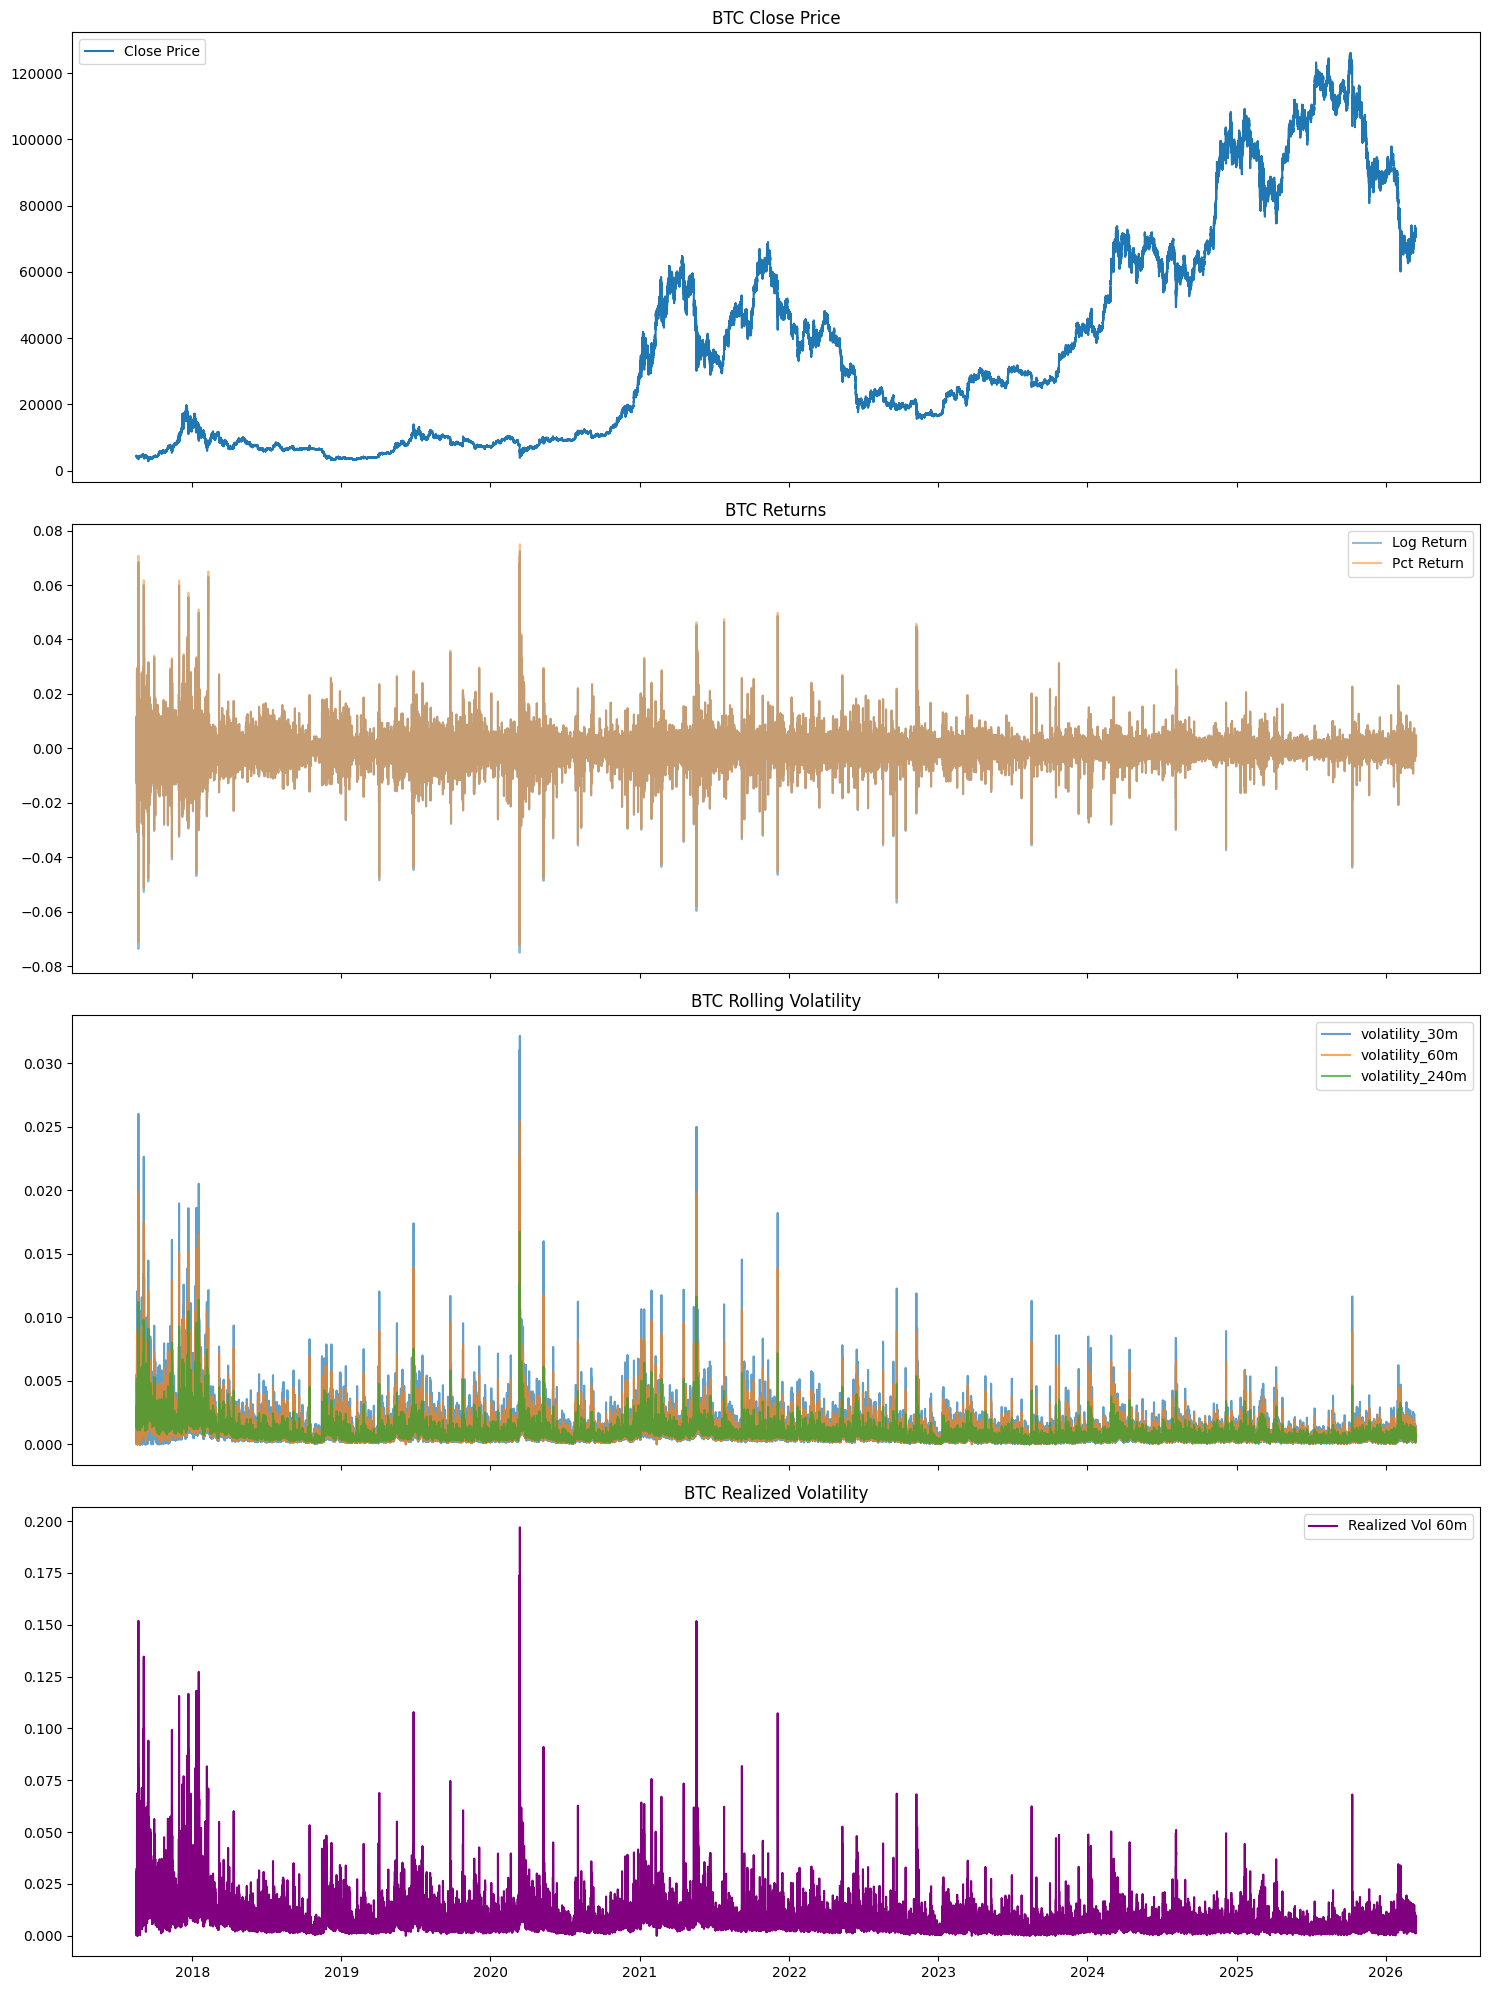

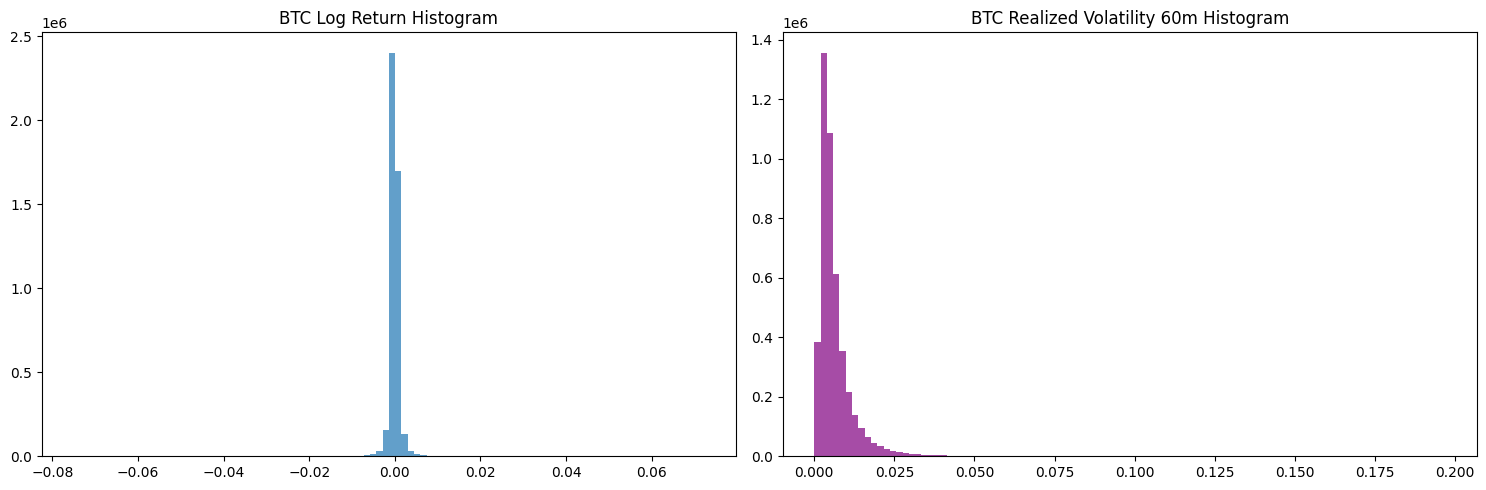

Plotting ETH...


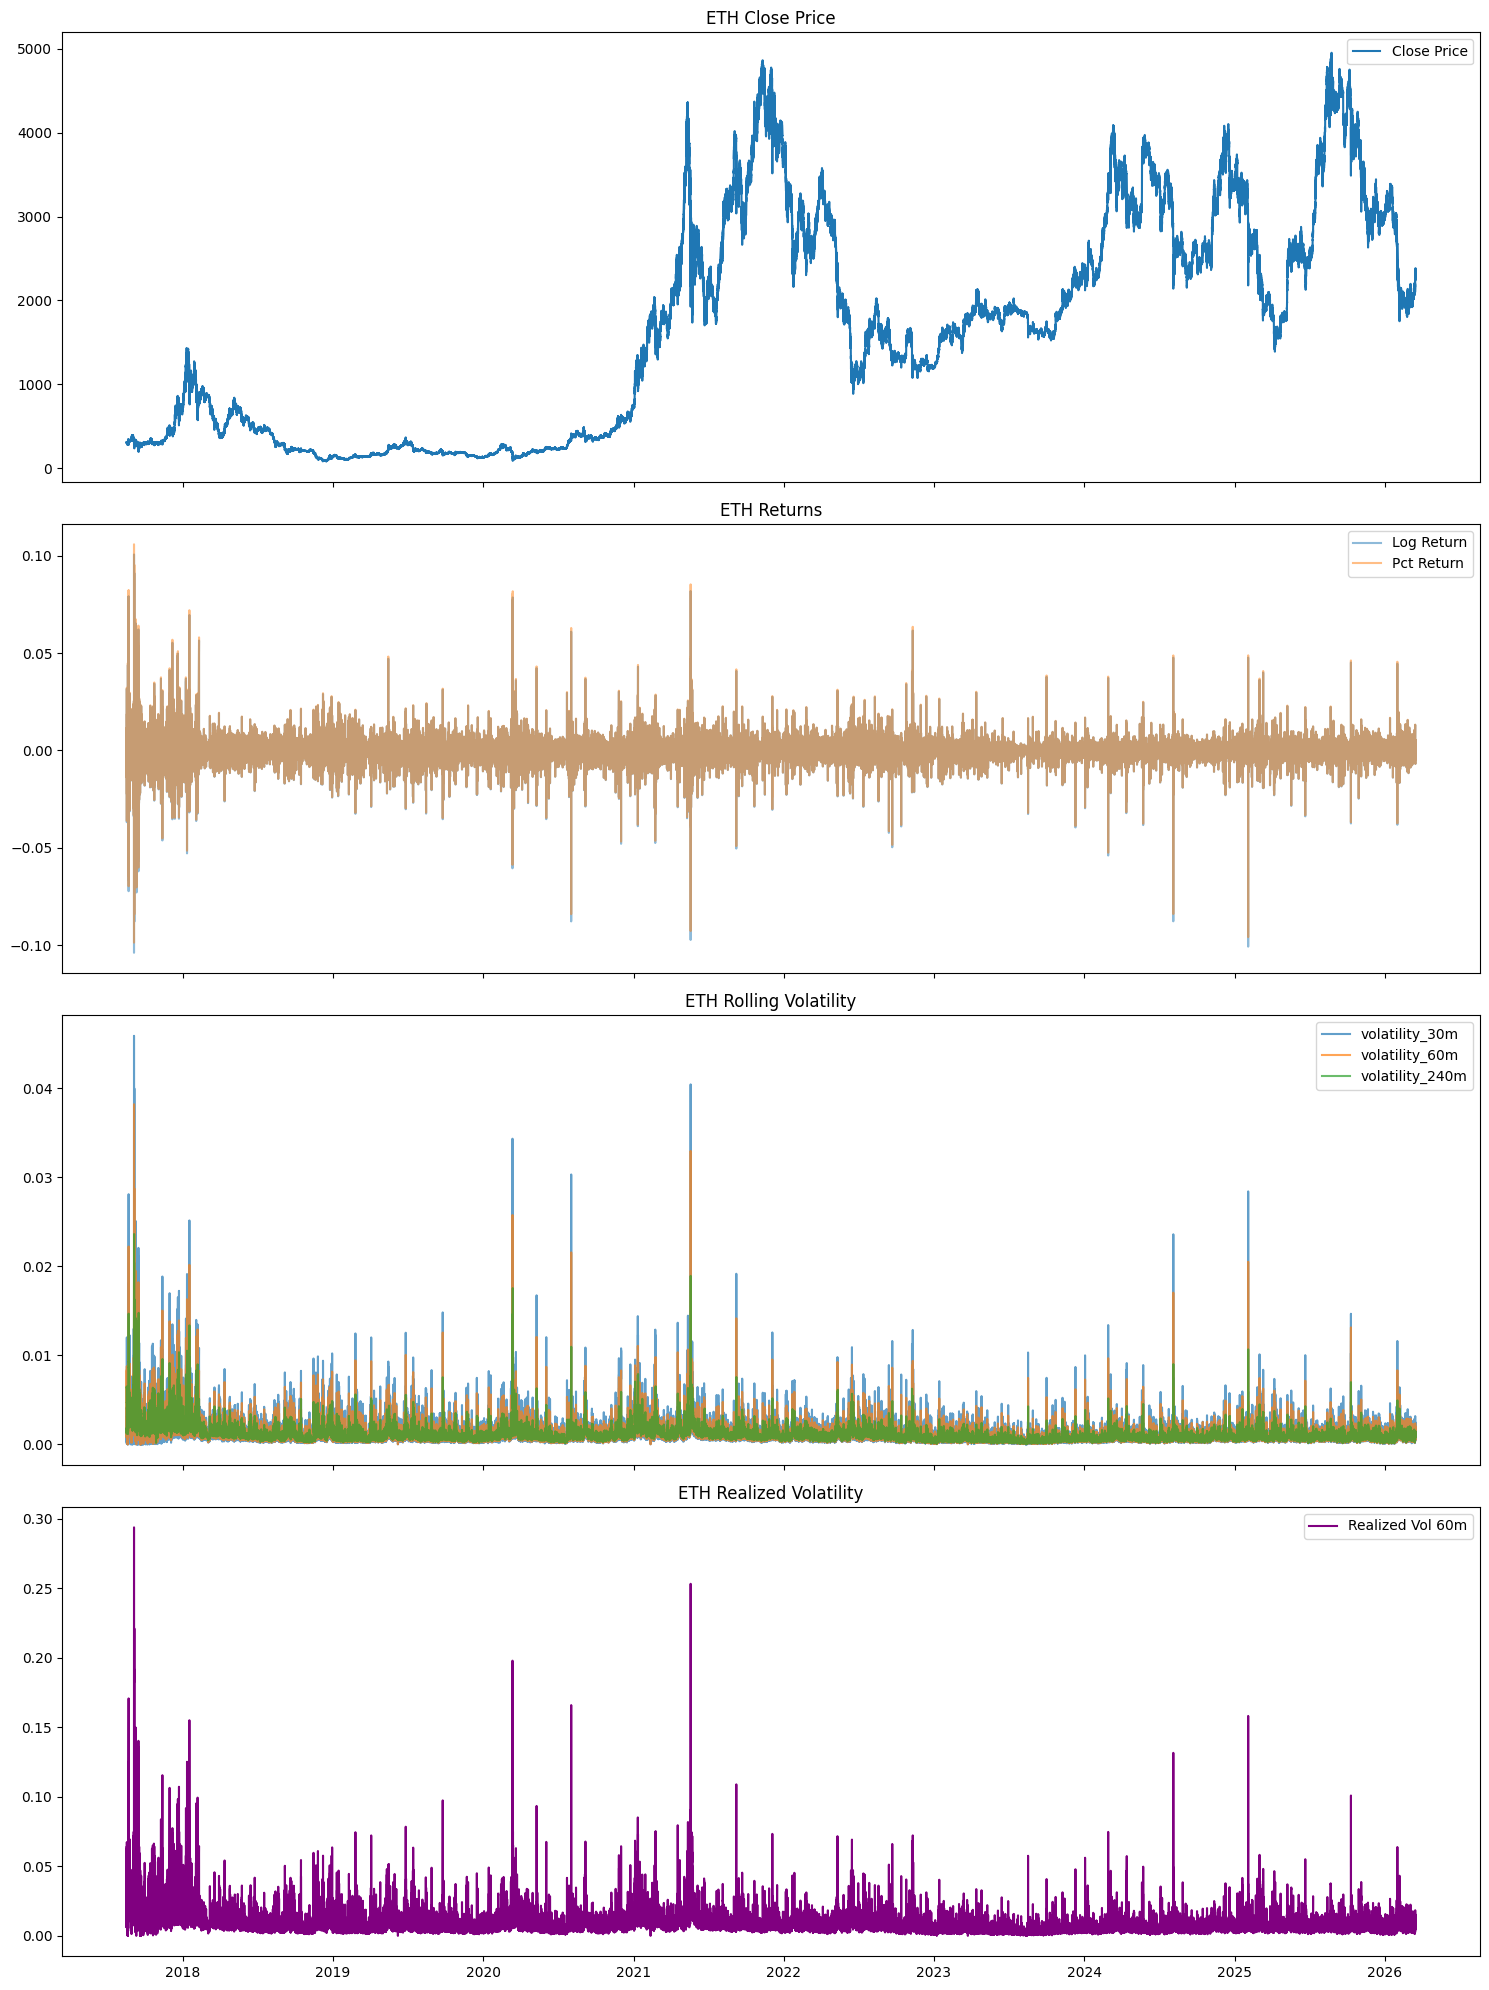

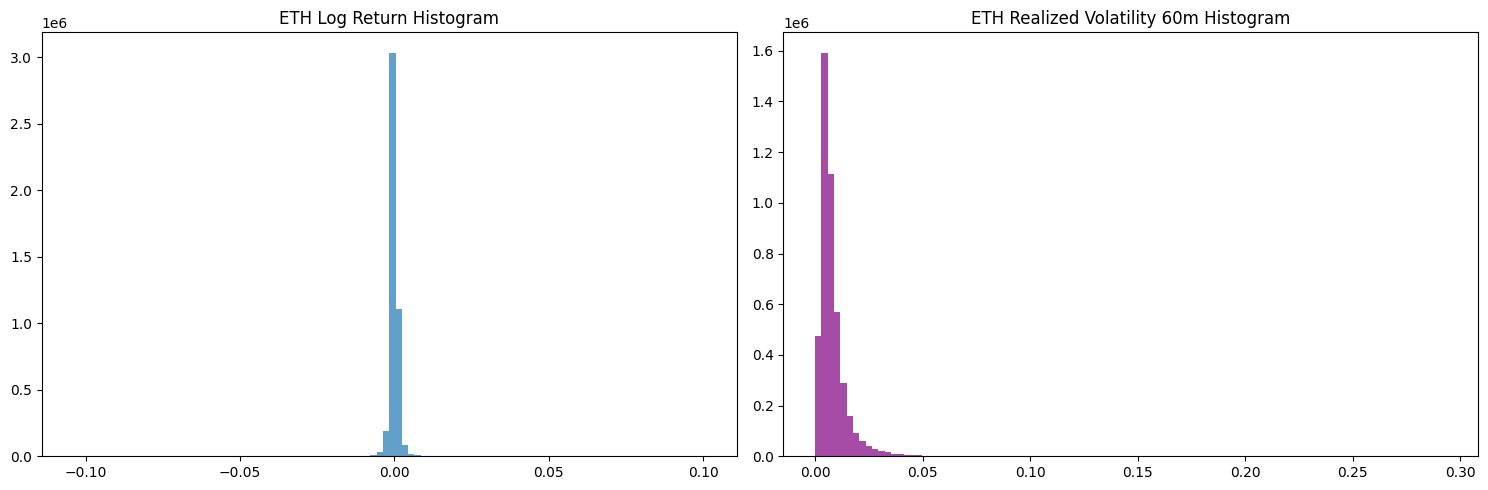

In [10]:
def plot_features(name, df):
    fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharex=True)
    
    # 1. Close price (full series)
    axes[0].plot(df['timestamp'], df['close'], label='Close Price')
    axes[0].set_title(f'{name} Close Price')
    axes[0].legend()
    
    # 2. Log return and pct return
    if 'log_return' in df.columns and 'pct_return' in df.columns:
        axes[1].plot(df['timestamp'], df['log_return'], alpha=0.5, label='Log Return')
        axes[1].plot(df['timestamp'], df['pct_return'], alpha=0.5, label='Pct Return')
        axes[1].set_title(f'{name} Returns')
        axes[1].legend()
    
    # 3. Rolling volatility
    vol_cols = [c for c in ['volatility_30m', 'volatility_60m', 'volatility_240m'] if c in df.columns]
    for col in vol_cols:
        axes[2].plot(df['timestamp'], df[col], alpha=0.7, label=col)
    axes[2].set_title(f'{name} Rolling Volatility')
    axes[2].legend()
    
    # 4. Realized volatility 60m
    if 'realized_volatility_60m' in df.columns:
        axes[3].plot(df['timestamp'], df['realized_volatility_60m'], color='purple', label='Realized Vol 60m')
        axes[3].set_title(f'{name} Realized Volatility')
        axes[3].legend()
        
    plt.tight_layout()
    plt.show()

    # Histograms
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    if 'log_return' in df.columns:
        axes[0].hist(df['log_return'].dropna(), bins=100, alpha=0.7)
        axes[0].set_title(f'{name} Log Return Histogram')
        
    if 'realized_volatility_60m' in df.columns:
        axes[1].hist(df['realized_volatility_60m'].dropna(), bins=100, alpha=0.7, color='purple')
        axes[1].set_title(f'{name} Realized Volatility 60m Histogram')
    
    plt.tight_layout()
    plt.show()

print("Plotting BTC...")
plot_features("BTC", df_btc)
print("Plotting ETH...")
plot_features("ETH", df_eth)

## 7. Comparative Plots

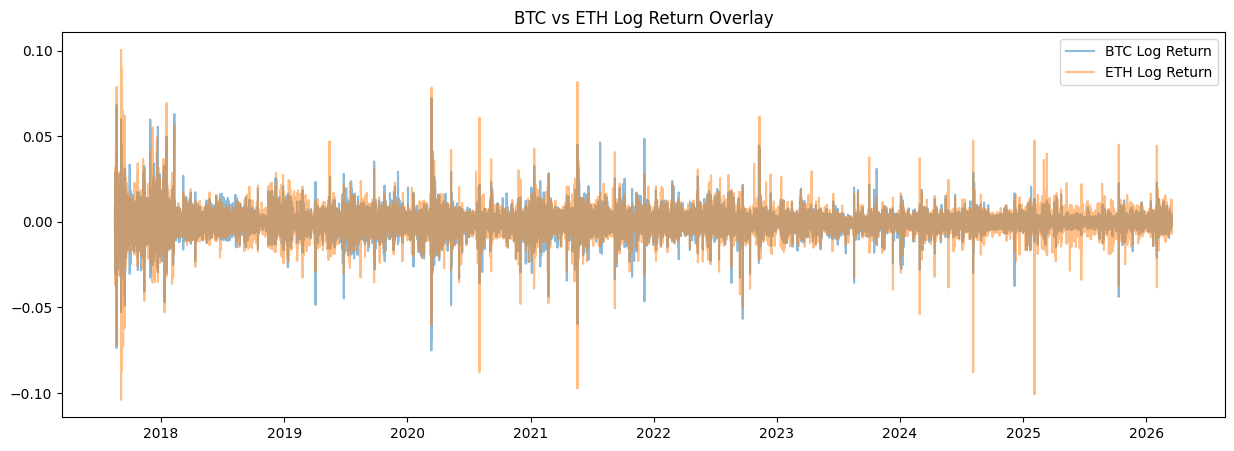

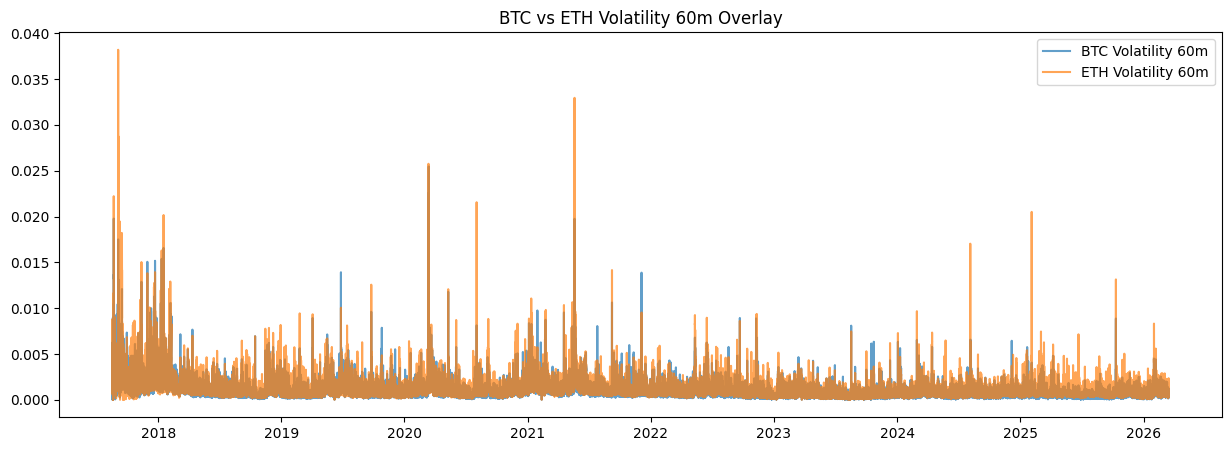

In [11]:
# Overlay BTC vs ETH log_return
plt.figure(figsize=(15, 5))
if 'log_return' in df_btc.columns and 'log_return' in df_eth.columns:
    plt.plot(df_btc['timestamp'], df_btc['log_return'], alpha=0.5, label='BTC Log Return')
    plt.plot(df_eth['timestamp'], df_eth['log_return'], alpha=0.5, label='ETH Log Return')
    plt.title('BTC vs ETH Log Return Overlay')
    plt.legend()
plt.show()

# Overlay volatility_60m
plt.figure(figsize=(15, 5))
if 'volatility_60m' in df_btc.columns and 'volatility_60m' in df_eth.columns:
    plt.plot(df_btc['timestamp'], df_btc['volatility_60m'], alpha=0.7, label='BTC Volatility 60m')
    plt.plot(df_eth['timestamp'], df_eth['volatility_60m'], alpha=0.7, label='ETH Volatility 60m')
    plt.title('BTC vs ETH Volatility 60m Overlay')
    plt.legend()
plt.show()

## 8. Stationarity Insight

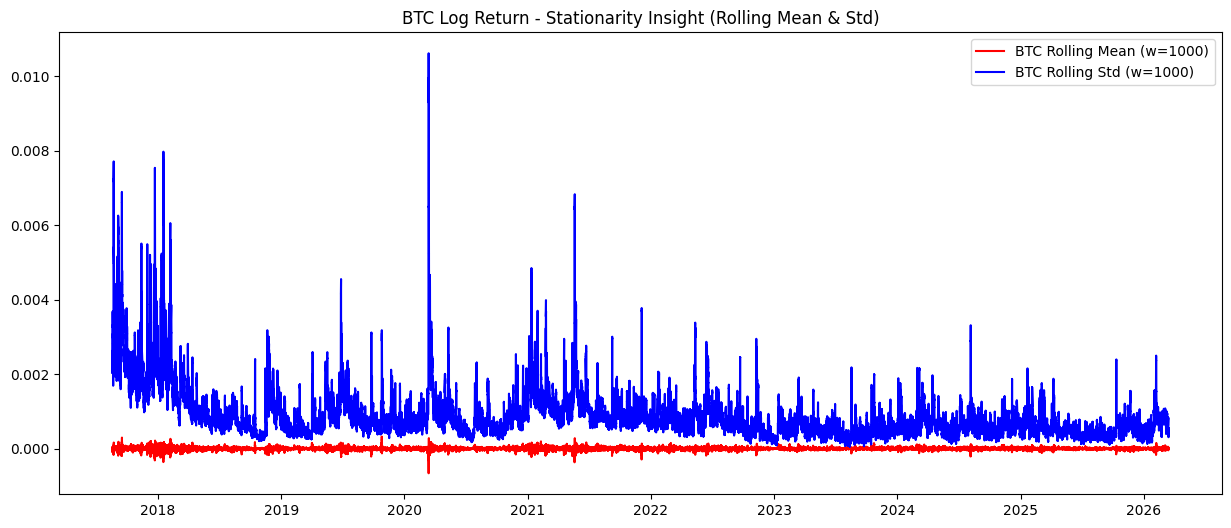

In [12]:
# Quick visual: Rolling mean and rolling std of log_return
if 'log_return' in df_btc.columns:
    plt.figure(figsize=(15, 6))
    
    rolling_mean_btc = df_btc['log_return'].rolling(window=1000).mean()
    rolling_std_btc = df_btc['log_return'].rolling(window=1000).std()
    
    plt.plot(df_btc['timestamp'], rolling_mean_btc, label='BTC Rolling Mean (w=1000)', color='red')
    plt.plot(df_btc['timestamp'], rolling_std_btc, label='BTC Rolling Std (w=1000)', color='blue')
    
    plt.title('BTC Log Return - Stationarity Insight (Rolling Mean & Std)')
    plt.legend()
    plt.show()

## 9. Output for Downstream Use

In [13]:
if 'log_return' in df_btc.columns:
    btc_log_return = df_btc["log_return"].dropna()
    print(f"Length of btc_log_return series: {len(btc_log_return)}")
    print(f"NaNs remaining in btc_log_return: {btc_log_return.isnull().sum()}")

if 'realized_volatility_60m' in df_btc.columns:
    btc_realized_vol = df_btc["realized_volatility_60m"].dropna()
    print(f"Length of btc_realized_vol series: {len(btc_realized_vol)}")
    print(f"NaNs remaining in btc_realized_vol: {btc_realized_vol.isnull().sum()}")

Length of btc_log_return series: 4502647
NaNs remaining in btc_log_return: 0
Length of btc_realized_vol series: 4502588
NaNs remaining in btc_realized_vol: 0


## 10. Summary and Next Steps

- **Which signal is most stable:** `log_return` appears to be the most stationary signal, exhibiting properties centered around zero with relatively stable variances over long periods.
- **Most suitable for motif discovery:** `log_return` is broadly accepted as the strongest candidate for motif discovery since motifs depend on scale-invariant and trend-free properties for meaningful local distances, minimizing the effect of non-stationary price drifts.
- **Impact of missing timestamps:** Unhandled gaps implicitly alter the distance profile sequences and can break consecutive motif boundaries, thus highlighting the crucial role of treating or flagging missing time rows accurately.
- **Recommend next step:** Proceed to the matrix profile formulation, utilizing `btc_log_return` to locate the dominant and informative motifs.